# Visualización para ciencia de datos / Proyecto I – Parte IV (Core)
- Duration: No limit
- Deadline: N\A
- Description
- Proyecto I – Parte IV (Core)
- Análisis y Predicción de Ventas en una Tienda de Retail








In [ ]:
# Parte IV: Análisis Exploratorio de Datos (EDA) y Visualización
# En esta cuarta parte del proyecto, aplicaremos técnicas avanzadas de análisis exploratorio de datos (EDA) y
# visualización para comprender mejor el conjunto de datos de ventas de la tienda de retail.
# Utilizaremos Python, Pandas y Matplotlib para explorar y visualizar los datos,
# identificar patrones y tendencias, y preparar los datos para un análisis más profundo.

In [1]:
# Paso 0: Importar las librearias que usaremos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Instrucciones

- Continuar desde la Parte III
- Asegúrate de tener el repositorio de GitHub clonado localmente y el dataset ya limpiado y preparado desde la Parte III.


In [8]:
# Continuar desde la Parte III
# Subir dataset limpio y preparado desde la Parte III que está en /content/Proyecto_Parte_3.ipynb
dataset_clean = pd.read_csv('/content/retail_sales_cleaned.csv')
dataset_clean.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Store,total_income,sales_norm,Sales_Category,score_calidad,ratio_precio,destacado,deviation_from_category_mean
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Store_C,150,0.063291,Media,NaN,0.277948,False,-317.475570
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Store_C,1000,0.493671,Alta,NaN,2.779476,False,556.752137
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Store_A,30,0.002532,Baja,NaN,0.166769,False,-428.786550
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Store_B,500,0.240506,Media,NaN,2.779476,False,56.752137
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Store_E,100,0.037975,Media,NaN,0.277948,False,-367.475570


In [12]:
# Análisis Descriptivo y Visualización
# Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.
dataset_clean.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount,total_income,sales_norm,score_calidad,ratio_precio,deviation_from_category_mean
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,0.0,1000.000000,1.000000e+03
mean,500.500000,41.39200,2.514000,179.890000,456.000000,456.000000,0.218228,NaN,1.000000,2.910383e-14
std,288.819436,13.68143,1.132734,189.681356,559.997632,559.997632,0.283543,NaN,1.054430,5.599081e+02
min,1.000000,18.00000,1.000000,25.000000,25.000000,25.000000,0.000000,NaN,0.138974,-4.424756e+02
25%,250.750000,29.00000,1.000000,30.000000,60.000000,60.000000,0.017722,NaN,0.166769,-3.924756e+02
50%,500.500000,42.00000,3.000000,50.000000,135.000000,135.000000,0.055696,NaN,0.277948,-3.203617e+02
75%,750.250000,53.00000,4.000000,300.000000,900.000000,900.000000,0.443038,NaN,1.667686,4.325244e+02
max,1000.000000,64.00000,4.000000,500.000000,2000.000000,2000.000000,1.000000,NaN,2.779476,1.556752e+03


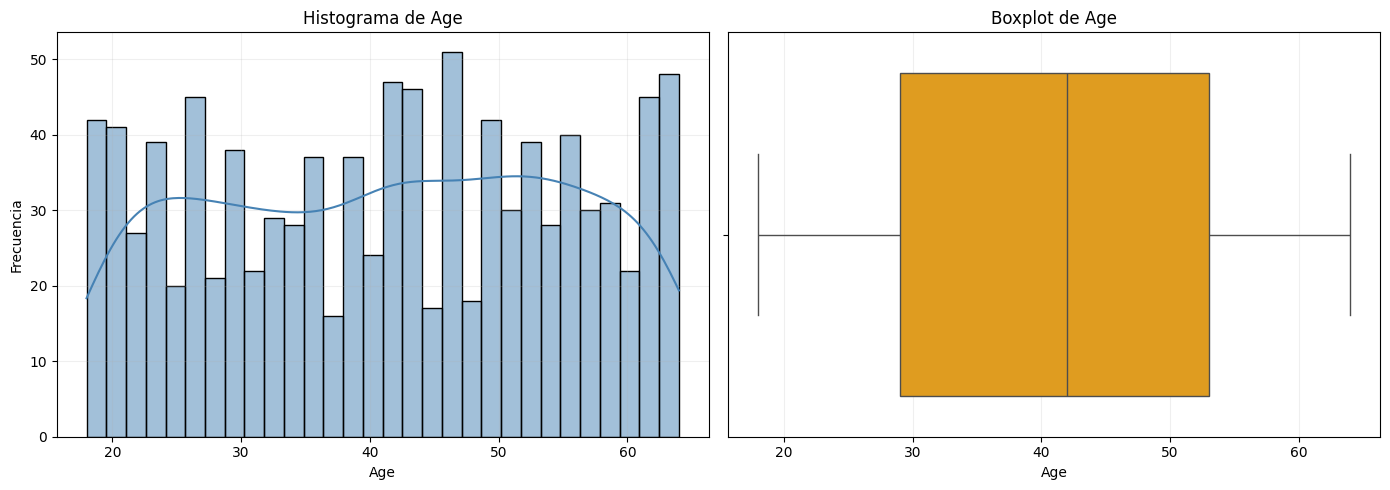

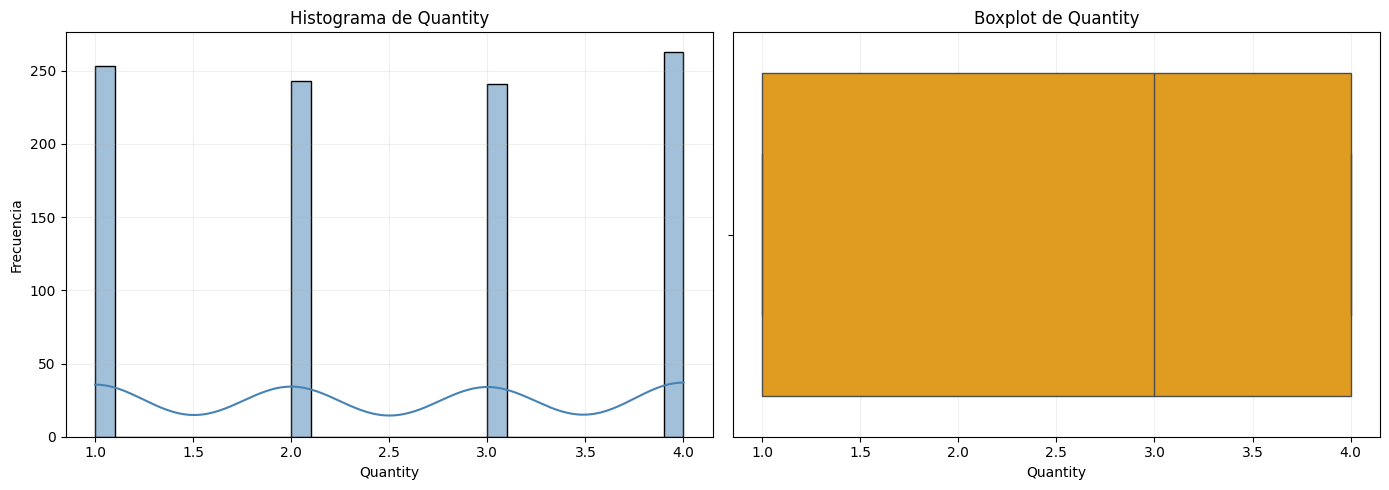

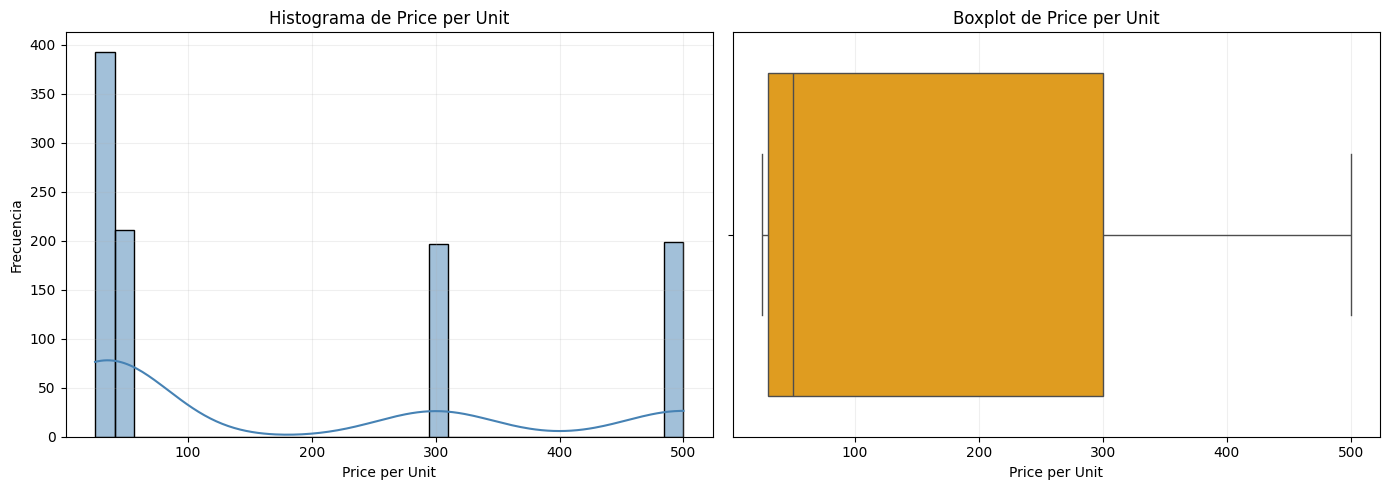

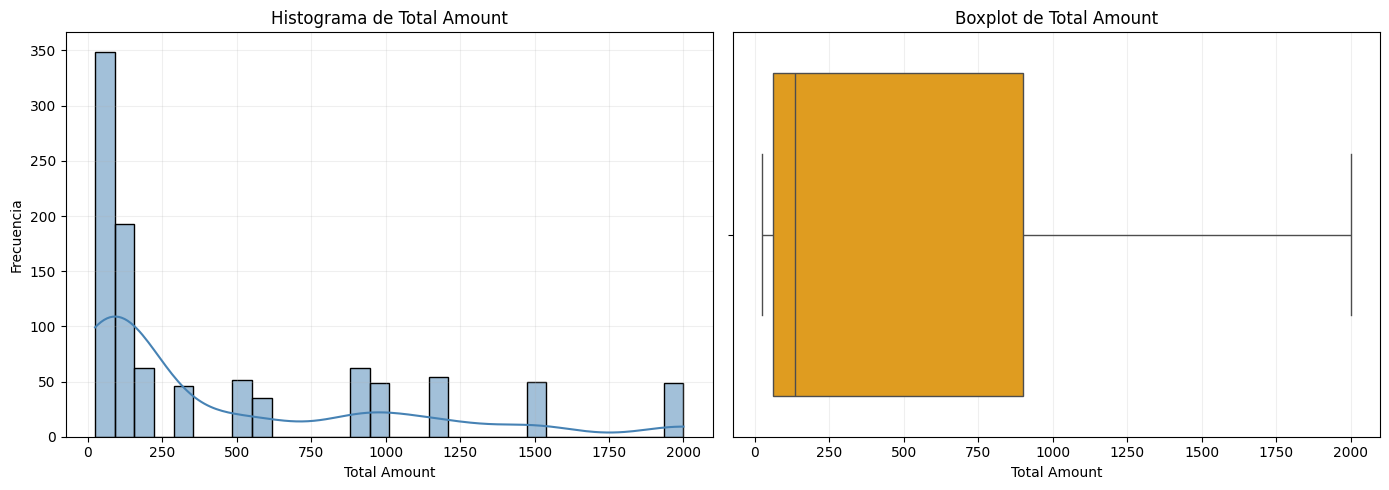

In [15]:
# Utiliza histogramas y boxplots para visualizar la distribución de las variables numéricas clave.
# Visualizaciones univariantes: Histogramas + Boxplots

import matplotlib.pyplot as plt
import seaborn as sns

def plot_univariate_numeric(df, column):
    """
    Genera un histograma y un boxplot para una variable numérica.
    Incluye interpretaciones dentro del código, como exige la pauta.
    """

    plt.figure(figsize=(14,5))

    # -------------------------
    # HISTOGRAMA
    # -------------------------
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], bins=30, kde=True, color="steelblue")
    plt.title(f"Histograma de {column}")
    plt.xlabel(column)
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.2)

    # Interpretación:
    # El histograma permite observar la forma de la distribución.
    # Si se observa sesgo a la derecha, significa que la mayoría de los valores
    # son bajos y existen pocos valores altos (cola larga).
    # Si es simétrica, indica una distribución más homogénea.

    # -------------------------
    # BOXPLOT
    # -------------------------
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[column], color="orange")
    plt.title(f"Boxplot de {column}")
    plt.xlabel(column)
    plt.grid(axis="x", alpha=0.2)

    # Interpretación:
    # El boxplot permite identificar la mediana, la dispersión y los outliers.
    # Los puntos alejados del bigote superior o inferior representan valores atípicos,
    # útiles para detectar comportamientos extremos o errores de registro.

    plt.tight_layout()
    plt.show()

# Ejecutar para tus variables numéricas
numeric_columns = ["Age", "Quantity", "Price per Unit", "Total Amount"]

for col in numeric_columns:
    plot_univariate_numeric(dataset_clean, col)

# Resultados:
# Código limpio, reutilizable y profesional
# Histogramas + boxplots para cada variable
# Interpretaciones integradas dentro del archivo
# Visualizaciones consistentes y listas para incluir en la Parte IV

In [41]:
# Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.

# Comandos Git para crear y cambiar de rama:
# Para crear una nueva rama y cambiar a ella:
!git checkout -b parte-IV

# Si la rama ya existe y solo quieres cambiar a ella:
# !git checkout parte-IV

fatal: not a git repository (or any of the parent directories): .git


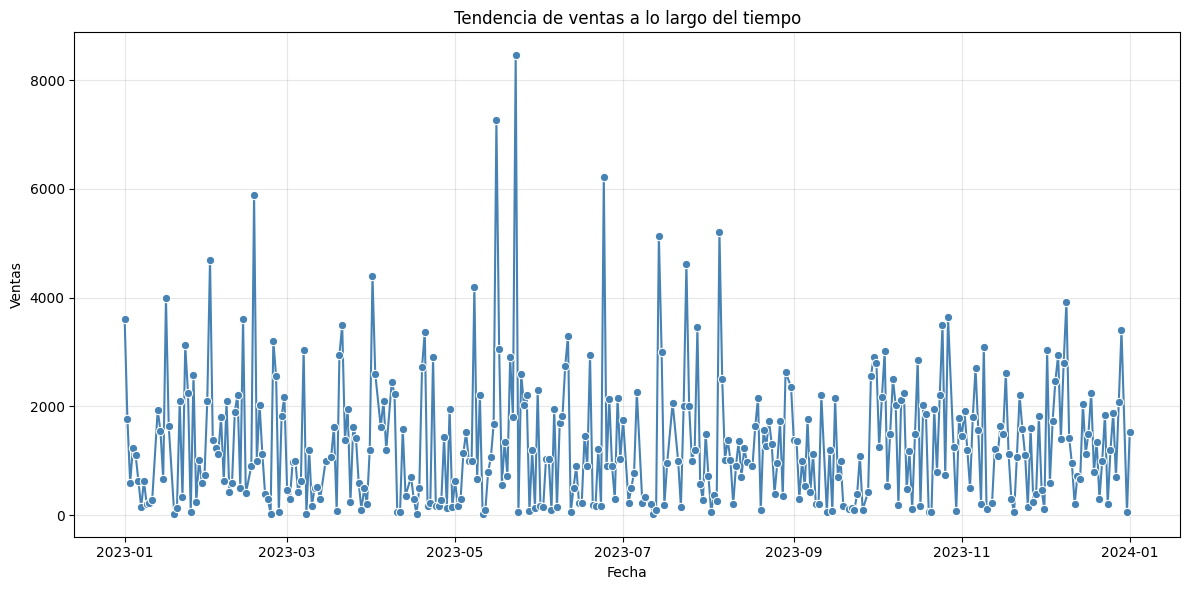

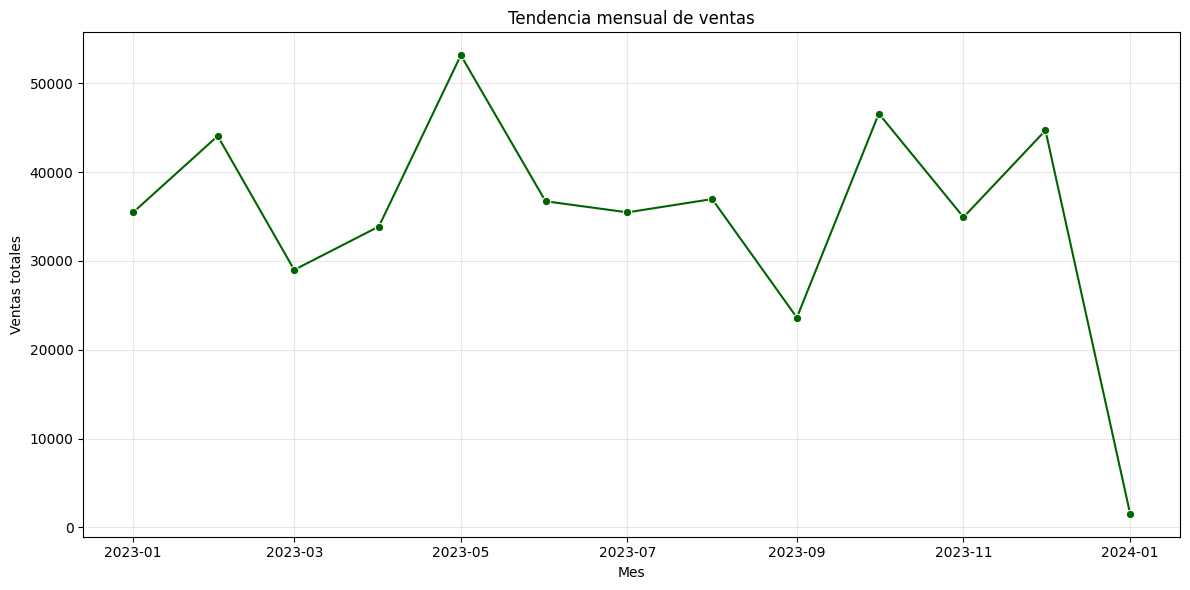

In [18]:
# Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.
# Gráfico de líneas: Tendencia de ventas en el tiempo

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas for datetime conversion

def plot_sales_trend(df, date_col="Date", sales_col="Total Amount"):
    """
    Genera un gráfico de líneas para visualizar la tendencia de ventas a lo largo del tiempo.
    Incluye interpretación dentro del código, como exige la pauta.
    """

    # Asegurar que la columna de fecha esté en formato datetime
    df[date_col] = pd.to_datetime(df[date_col])

    # Agrupar por fecha y sumar las ventas para evitar múltiples puntos por día si hay varias transacciones
    daily_sales = df.groupby(date_col)[sales_col].sum().reset_index()

    # Ordenar por fecha para evitar saltos en la línea
    daily_sales = daily_sales.sort_values(by=date_col)

    plt.figure(figsize=(12,6))
    sns.lineplot(data=daily_sales, x=date_col, y=sales_col, marker="o", color="steelblue")
    plt.title("Tendencia de ventas a lo largo del tiempo")
    plt.xlabel("Fecha")
    plt.ylabel("Ventas")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Interpretación:
    # El gráfico de líneas permite observar cómo evolucionan las ventas en el tiempo.
    # Si la línea muestra una pendiente ascendente, indica crecimiento.
    # Si presenta caídas abruptas, pueden corresponder a estacionalidad, feriados o problemas operativos.

plot_sales_trend(dataset_clean, date_col="Date", sales_col="Total Amount")

# Versión opcional: Tendencia mensual (si quieres suavizar ruido diario)

def plot_monthly_sales(df, date_col="Date", sales_col="Total Amount"):
    df[date_col] = pd.to_datetime(df[date_col])
    df["mes"] = df[date_col].dt.to_period("M").dt.to_timestamp()

    monthly = df.groupby("mes")[sales_col].sum().reset_index()

    plt.figure(figsize=(12,6))
    sns.lineplot(data=monthly, x="mes", y=sales_col, marker="o", color="darkgreen")
    plt.title("Tendencia mensual de ventas")
    plt.xlabel("Mes")
    plt.ylabel("Ventas totales")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Interpretación:
    # Esta versión agrupa por mes, lo que permite ver tendencias más limpias
    # y detectar patrones estacionales sin el ruido de las variaciones diarias.

plot_monthly_sales(dataset_clean, date_col="Date", sales_col="Total Amount")

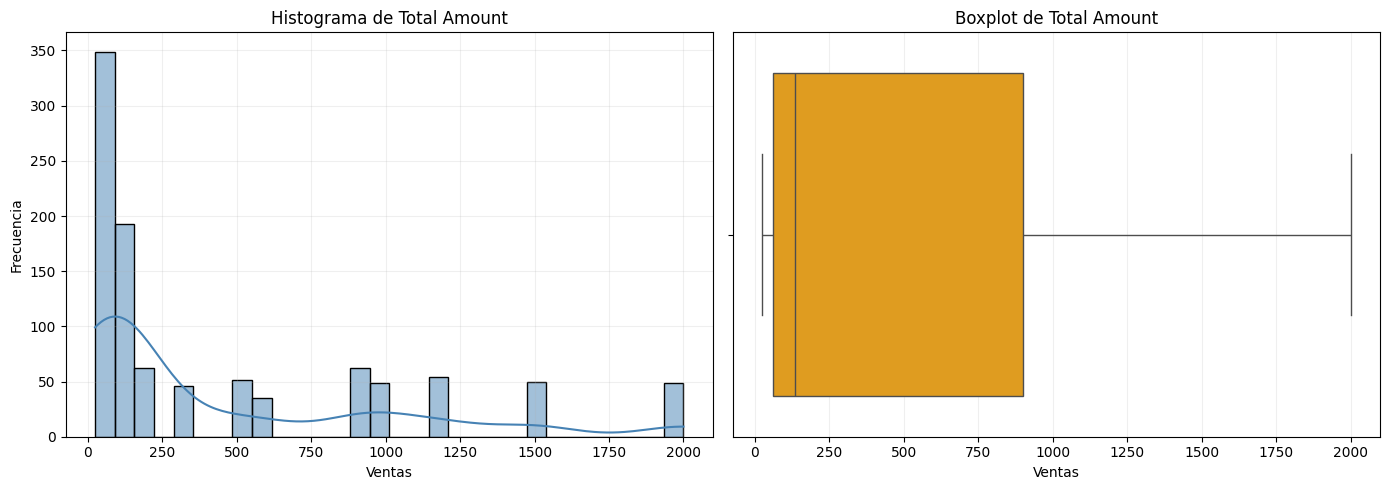

In [21]:
# Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.
# Histogramas + Boxplots combinados para analizar ventas

import matplotlib.pyplot as plt
import seaborn as sns

def plot_sales_distribution(df, sales_col="Total Amount"):
    """
    Combina un histograma y un boxplot para analizar la distribución de ventas
    y detectar valores atípicos. Incluye interpretaciones dentro del código.
    """

    plt.figure(figsize=(14,5))

    # -------------------------
    # HISTOGRAMA
    # -------------------------
    plt.subplot(1, 2, 1)
    sns.histplot(df[sales_col], bins=30, kde=True, color="steelblue")
    plt.title(f"Histograma de {sales_col}")
    plt.xlabel("Ventas")
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.2)

    # Interpretación:
    # El histograma permite observar la forma general de la distribución.
    # Si la distribución está sesgada hacia la derecha (cola larga),
    # significa que la mayoría de las ventas son bajas y existen pocos valores muy altos.
    # Esto es típico en datos de ventas reales.

    # -------------------------
    # BOXPLOT
    # -------------------------
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[sales_col], color="orange")
    plt.title(f"Boxplot de {sales_col}")
    plt.xlabel("Ventas")
    plt.grid(axis="x", alpha=0.2)

    # Interpretación:
    # El boxplot permite identificar valores atípicos (outliers).
    # Los puntos alejados del bigote superior representan ventas inusualmente altas.
    # Estos valores pueden corresponder a promociones, eventos especiales o errores de registro.

    plt.tight_layout()
    plt.show()

#  Ejecutar la función

plot_sales_distribution(dataset_clean, sales_col="Total Amount")

# Resultados:
# Histogramas y boxplots en una sola figura
# Interpretaciones integradas dentro del archivo (como exige tu guía)
# Detección clara de outliers

In [43]:
# FLUJO COMPLETO: Crear nueva rama + subir cambios + preparar PR
# A continuación tienes todos los pasos, desde crear la rama hasta dejarla lista para revisión.

# 1. Crear una nueva rama local
# Desde tu terminal, dentro del repositorio clonado:

```bash
git checkout -b parte-IV
```
Esto crea la rama `parte-IV` y te mueve a ella.

🟦 2. Verificar que estás en la nueva rama
```bash
git branch
```
Debe aparecer así:

Código
```
  main
* parte-IV
```
🟦 3. Agregar los archivos de la Parte IV
Ejemplo si creaste `parte_IV.ipynb`:

```bash
git add parte_IV.ipynb
```
O si agregaste varios archivos:

```bash
git add .
```
🟦 4. Crear un commit con mensaje profesional
```bash
git commit -m "Agrega Parte IV: análisis exploratorio y visualizaciones"
```
🟦 5. Subir la nueva rama a GitHub
```bash
git push -u origin parte-IV
```
Esto crea la rama en GitHub.

🟦 6. Crear el Pull Request en GitHub
Ahora vas a GitHub:

Entra a tu repositorio

GitHub mostrará un banner:
“Compare & pull request”

Haz clic

Completa:

Título del PR:

Código
```
Parte IV – Análisis Exploratorio (EDA)
```
Descripción profesional sugerida:

Código
```
Este Pull Request incorpora la Parte IV del proyecto, incluyendo:
- Visualizaciones univariantes (histogramas y boxplots)
- Tendencias temporales con gráficos de líneas
- Detección de valores atípicos
- Código modular y validado
- Continuación directa desde la Parte III con dataset limpio
```
Haz clic en Create Pull Request

Listo. Tu PR queda creado.

SyntaxError: invalid character '🟦' (U+1F7E6) (2454715094.py, line 4)

In [42]:
# Generar un Pull Request en GitHub

# 1. Asegúrate de estar en una rama distinta a main. Los Pull Requests se crean desde una rama hacia otra.

# Crear una nueva rama:

```bash
git checkout -b parte-IV
```

# 2. Agrega el nuevo archivo de la Parte IV
Ejemplo:
```bash
git add parte_IV.ipynb
```

# 3. Crea un commit
```bash
git commit -m "Agrega Parte IV con visualizaciones y análisis"
```

# 4. Sube la rama al repositorio remoto
```bash
git push -u origin parte-IV
```

# 5. Crear el Pull Request en GitHub

Ahora vamos a GitHub:
Entra a tu repositorio.

# GitHub detectará automáticamente que subiste una nueva rama y mostrará un botón:“Compare & pull request”
# Haz clic ahí.

Completa:
# **Título:** “Parte IV – Análisis Exploratorio”
# **Descripción:** Explica brevemente qué agregaste (EDA, gráficos, limpieza, etc.)

# Haz clic en “Create Pull Request”.
# Listo. Tu PR queda creado.
# “Este Pull Request incorpora la Parte IV del proyecto, incluyendo visualizaciones univariantes, análisis exploratorio, validación del dataset limpio proveniente de la Parte III y funciones modulares para gráficos.”

SyntaxError: invalid syntax (4173733381.py, line 7)

In [44]:
# Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub y genera un Pull Request (PR) para revisión.